# SegFormer MAE Internals — Step-by-Step Visualization

This notebook dissects the SegFormer Masked Autoencoder for thermal anomaly detection,
running a single 256x256 patch through every stage of the model and visualizing the
intermediate representations.

**What you will see:**
1. The raw thermal patch extracted from benchmark Dataset 1
2. Pixel masking (validity) and z-score normalization
3. Stage 1 Overlap Patch Embedding (OPE) — how the image becomes 64x64 tokens
4. Token removal — which tokens the MAE hides from the encoder
5. Stage 1 transformer block — attention enriches token representations
6. Scatter-back — zeros fill the removed token positions
7. Stages 2-4 feature maps at progressively coarser resolutions
8. Decoder fusion — multi-scale features merged at H/4 resolution
9. Refine convolutions and PixelShuffle — learned upsampling to full resolution
10. Reconstruction vs. original, and the residual anomaly map

**Model configuration:** matches `seg_former_exp_7.json`
- embed_dims: [16, 32, 64, 96], num_heads: [1, 2, 4, 8]
- reduction_ratios: [8, 4, 2, 1], num_blocks: [1, 1, 1, 1]
- decoder_dim: 96, expansion_ratio: 2, mask_ratio: 0.5

### 1. Imports and Setup

In [1]:
import os
import sys
import json
import pathlib

import numpy as np
import torch
import torch.nn.functional as F
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Project root (two levels up from benchmarking/thermal/)
PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parents[1])
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.landsat_dataset_builder import LandsatDataBuilder
from app.foundation_models.components.seg_former_mae import SegFormerMAE
from app.foundation_models.components.token_masking import TokenMasking

# Use CPU for deterministic exploration (change to "mps" or "cuda" if desired)
DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")
print(f"Project root: {PROJECT_ROOT}")

Using device: cpu
Project root: /Users/ashwinravi/Desktop/Code Repos/hsi-anomaly-foundations-allotrope


### 2. Load Benchmark Dataset 1

We use `LandsatDataBuilder` to load the thermal scene, then extract a 256x256 patch
from the center of the valid region. Ground truth anomaly labels are loaded from `gt.tif`.

In [80]:
BENCHMARK_ROOT = os.path.join(PROJECT_ROOT, "benchmarking", "thermal")
folder = os.path.join(BENCHMARK_ROOT, "1")

# Find the thermal TIF
tif_files = [f for f in os.listdir(folder) if f.endswith(".TIF")]
assert len(tif_files) == 1, f"Expected 1 TIF in {folder}, found {tif_files}"
tif_path = os.path.join(folder, tif_files[0])
gt_path = os.path.join(folder, "gt.tif")

print(f"Loading: {tif_files[0]}")
builder = LandsatDataBuilder(
    file_source_configuration=FileSourceConfig(source_path=tif_path)
)
vendable = builder.vend_dataset()

# Extract arrays from the vendable dataset
thermal_cube = vendable.normalized_thermal_cube  # (1, H, W) in Celsius
validity_mask = vendable.pure_validity_mask  # (1, H, W) binary
cloud_mask = vendable.cloud_mask   # (1, H, W) binary

# Combined mask: valid AND not cloud
combined_mask = (validity_mask * cloud_mask).astype(np.float32)

# Ground truth anomalies
with rasterio.open(gt_path) as src:
    gt_data = src.read(1)  # (H, W)

_, H_scene, W_scene = thermal_cube.shape
print(f"Scene shape: {thermal_cube.shape}")
print(f"Valid pixels: {int(combined_mask.sum()):,}")
print(f"Anomaly pixels: {int(gt_data.sum()):,}")
print(f"Temp range: [{thermal_cube[combined_mask > 0].min():.1f}, {thermal_cube[combined_mask > 0].max():.1f}] C")

Loading: LC09_L2SP_141045_20250604_20250605_02_T1_ST_B10.TIF
Using device: mps
Max Temp = 80.34671783447266
Min Temp = -124.1500015258789
Masked Array
(40711448, 1)
[ 5.70057964 30.2351265  36.49352264 42.5639267  45.11376953]
Anchors Set to [[-10.        ]
 [  5.        ]
 [ 36.49352264]
 [ 42.5639267 ]
 [ 45.11376953]]
24.49352264404297
[0 1]
Scene shape: (1, 7681, 7521)
Valid pixels: 38,737,632
Anomaly pixels: 6,636
Temp range: [23.7, 46.6] C


### 3. Extract a 256x256 Patch from the Center

We pick a patch from the center of the scene where validity is high. The patch
is converted to a torch tensor with shape `(1, 1, 256, 256)` — batch size 1,
single thermal channel.

In [99]:
PATCH_SIZE = 256

# Center crop coordinates
r0 = (H_scene - PATCH_SIZE) // 6
c0 = (W_scene - PATCH_SIZE) // 6

patch_thermal = thermal_cube[:, r0:r0+PATCH_SIZE, c0:c0+PATCH_SIZE]  # (1, 256, 256)
patch_mask = combined_mask[:, r0:r0+PATCH_SIZE, c0:c0+PATCH_SIZE]     # (1, 256, 256)
patch_gt = gt_data[r0:r0+PATCH_SIZE, c0:c0+PATCH_SIZE]                # (256, 256)

# Convert to torch tensors — add batch dimension
pixels = torch.tensor(patch_thermal, dtype=torch.float32).unsqueeze(0).to(DEVICE)   # (1, 1, 256, 256)
mask = torch.tensor(patch_mask, dtype=torch.float32).unsqueeze(0).to(DEVICE)         # (1, 1, 256, 256)

valid_frac = patch_mask.mean()
print(f"Patch location: row={r0}, col={c0}")
print(f"Patch shape: {pixels.shape}")
print(f"Valid fraction: {valid_frac:.2%}")
print(f"Anomaly pixels in patch: {int(patch_gt.sum())}")
print(f"Patch temp range: [{patch_thermal[patch_mask > 0].min():.1f}, {patch_thermal[patch_mask > 0].max():.1f}] C")

Patch location: row=1237, col=1210
Patch shape: torch.Size([1, 1, 256, 256])
Valid fraction: 100.00%
Anomaly pixels in patch: 0
Patch temp range: [30.0, 39.4] C


### 4. Visualize the Original 256x256 Patch

The raw thermal patch in degrees Celsius, displayed with the `inferno` colormap.
Brighter regions are hotter.

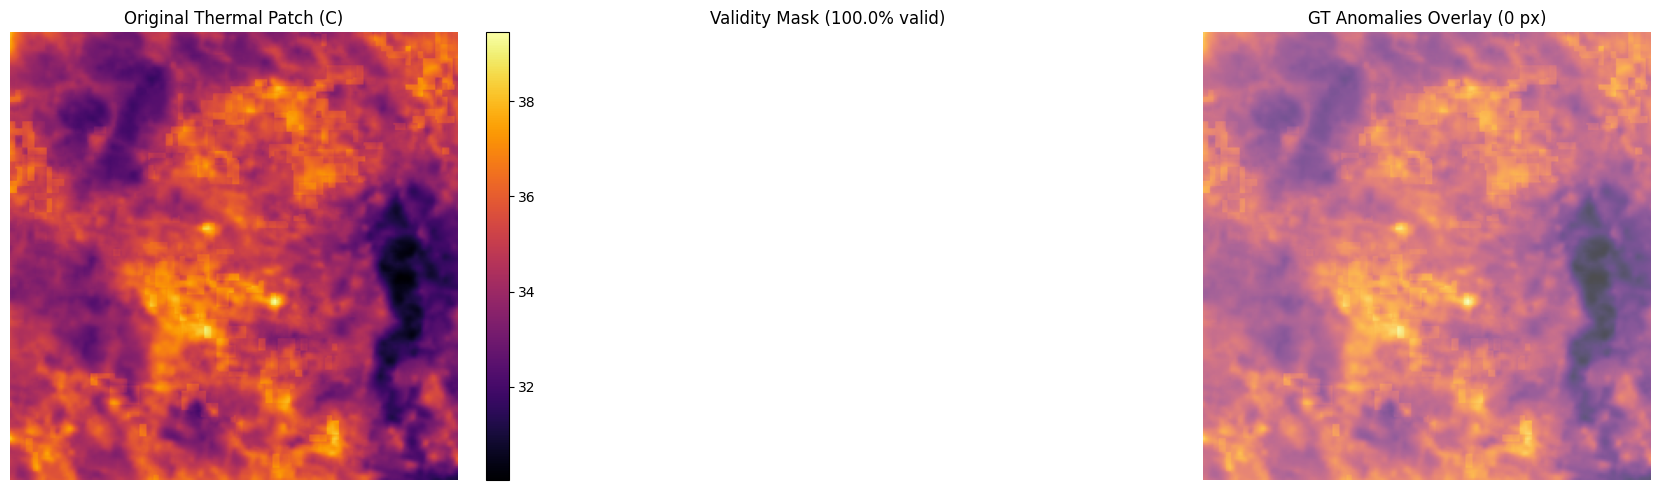

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original thermal patch
im0 = axes[0].imshow(patch_thermal[0], cmap="inferno")
axes[0].set_title("Original Thermal Patch (C)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Validity mask
axes[1].imshow(patch_mask[0], cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Validity Mask ({valid_frac:.1%} valid)")

# Ground truth anomalies
axes[2].imshow(patch_thermal[0], cmap="inferno", alpha=0.7)
if patch_gt.sum() > 0:
    axes[2].imshow(np.ma.masked_where(patch_gt == 0, patch_gt),
                   cmap="Reds", alpha=0.8, vmin=0, vmax=1)
axes[2].set_title(f"GT Anomalies Overlay ({int(patch_gt.sum())} px)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 5. Build the SegFormer MAE Model

Instantiate the model with the `seg_former_exp_7.json` configuration.
Pixel normalization stats come from `thermal_pixel_consts.json`.

**Checkpoint loading:** Update `CHECKPOINT_PATH` to point to your trained checkpoint.
If no checkpoint is available, the model runs with random weights (useful for
understanding the architecture flow, though reconstructions will be meaningless).

In [101]:
# --- Model configuration (matches seg_former_exp_7.json) ---
MODEL_CONFIG = {
    "in_channels": 1,
    "embed_dims": [16, 32, 64, 96],
    "num_heads": [1, 2, 4, 8],
    "reduction_ratios": [8, 4, 2, 1],
    "num_blocks": [1, 1, 1, 1],
    "decoder_dim": 96,
    "expansion_ratio": 2,
    "drop_rate": 0.0,  # No dropout for inference
}

# Load pixel normalization stats
PIXEL_STATS_PATH = os.path.join(PROJECT_ROOT, "app", "constants", "thermal_pixel_consts.json")
with open(PIXEL_STATS_PATH) as f:
    stats = json.load(f)
pixel_mean = stats["mean"]
pixel_std = stats["std"]
print(f"Pixel stats: mean={pixel_mean}, std={pixel_std}")

# Build model
model = SegFormerMAE(
    **MODEL_CONFIG,
    pixel_mean=pixel_mean,
    pixel_std=pixel_std,
).to(DEVICE)
model.eval()

# --- Load checkpoint (update this path!) ---
# CHECKPOINT_PATH = "/path/to/your/checkpoint.pt"
CHECKPOINT_PATH = "/Users/ashwinravi/Desktop/Code Repos/hsi-anomaly-foundations-allotrope/checkpoints/segformer_mae_v0.8.0_epoch495.pt"  # Set to None to run with random weights

if CHECKPOINT_PATH is not None and os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict)
    print(f"Loaded checkpoint from: {CHECKPOINT_PATH}")
else:
    print("WARNING: No checkpoint loaded — running with random weights.")
    print("Update CHECKPOINT_PATH above to load a trained model.")

# Count parameters
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Pixel stats: mean=[24.57564215918313], std=[13.574351624314858]
Loaded checkpoint from: /Users/ashwinravi/Desktop/Code Repos/hsi-anomaly-foundations-allotrope/checkpoints/segformer_mae_v0.8.0_epoch495.pt
Model parameters: 406,496


### 6. Step A — Pixel Masking and Normalization

The model first zeros out invalid pixels (via the validity mask), then normalizes
to z-score space: `x_norm = (x - mean) / std`.

Invalid pixels become `(0 - 24.6) / 13.6 ~ -1.8` in normalized space — a clear
out-of-distribution signal that tells the encoder "this pixel has no real data."

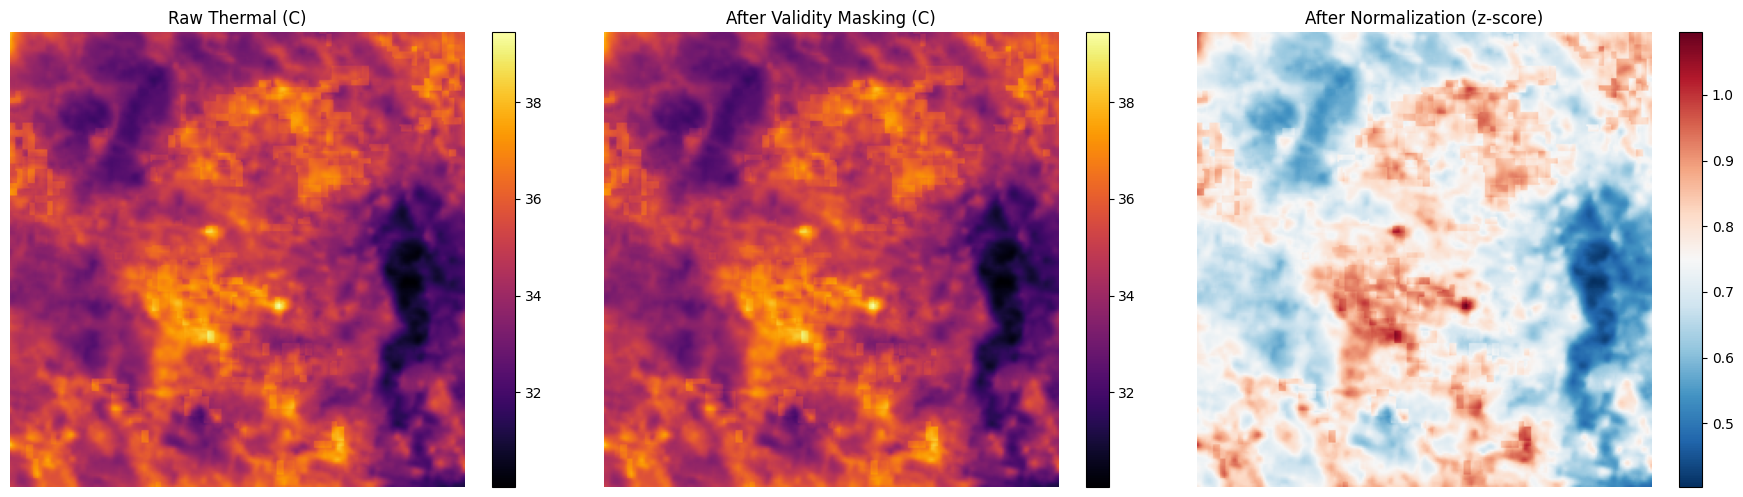

Normalized range: [0.40, 1.10]
Invalid pixel value in normalized space: nan


In [102]:
with torch.no_grad():
    # Step 1: Zero out invalid pixels
    x_masked = pixels * mask  # (1, 1, 256, 256)

    # Step 2: Normalize to z-score space
    x_norm = model.normalize(x_masked)  # (1, 1, 256, 256)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(pixels[0, 0].numpy(), cmap="inferno")
axes[0].set_title("Raw Thermal (C)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(x_masked[0, 0].numpy(), cmap="inferno")
axes[1].set_title("After Validity Masking (C)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(x_norm[0, 0].numpy(), cmap="RdBu_r")
axes[2].set_title("After Normalization (z-score)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Normalized range: [{x_norm[mask > 0].min():.2f}, {x_norm[mask > 0].max():.2f}]")
print(f"Invalid pixel value in normalized space: {x_norm[mask == 0].mean():.2f}")

### 7. Step B — Stage 1 Overlap Patch Embedding (OPE)

The first OPE uses `kernel_size=4, stride=4, padding=0` — **non-overlapping** patches.
Each 4x4 pixel block becomes one token. A 256x256 image yields a 64x64 grid of 4096 tokens,
each with `embed_dim=16` channels.

The Conv2d acts as a learned linear projection of each 4x4 block into embedding space,
followed by LayerNorm per token.

Stage 1 OPE output: torch.Size([1, 4096, 16])  (B, N=64x64, C=16)
Token grid: 64 x 64 = 4096 tokens


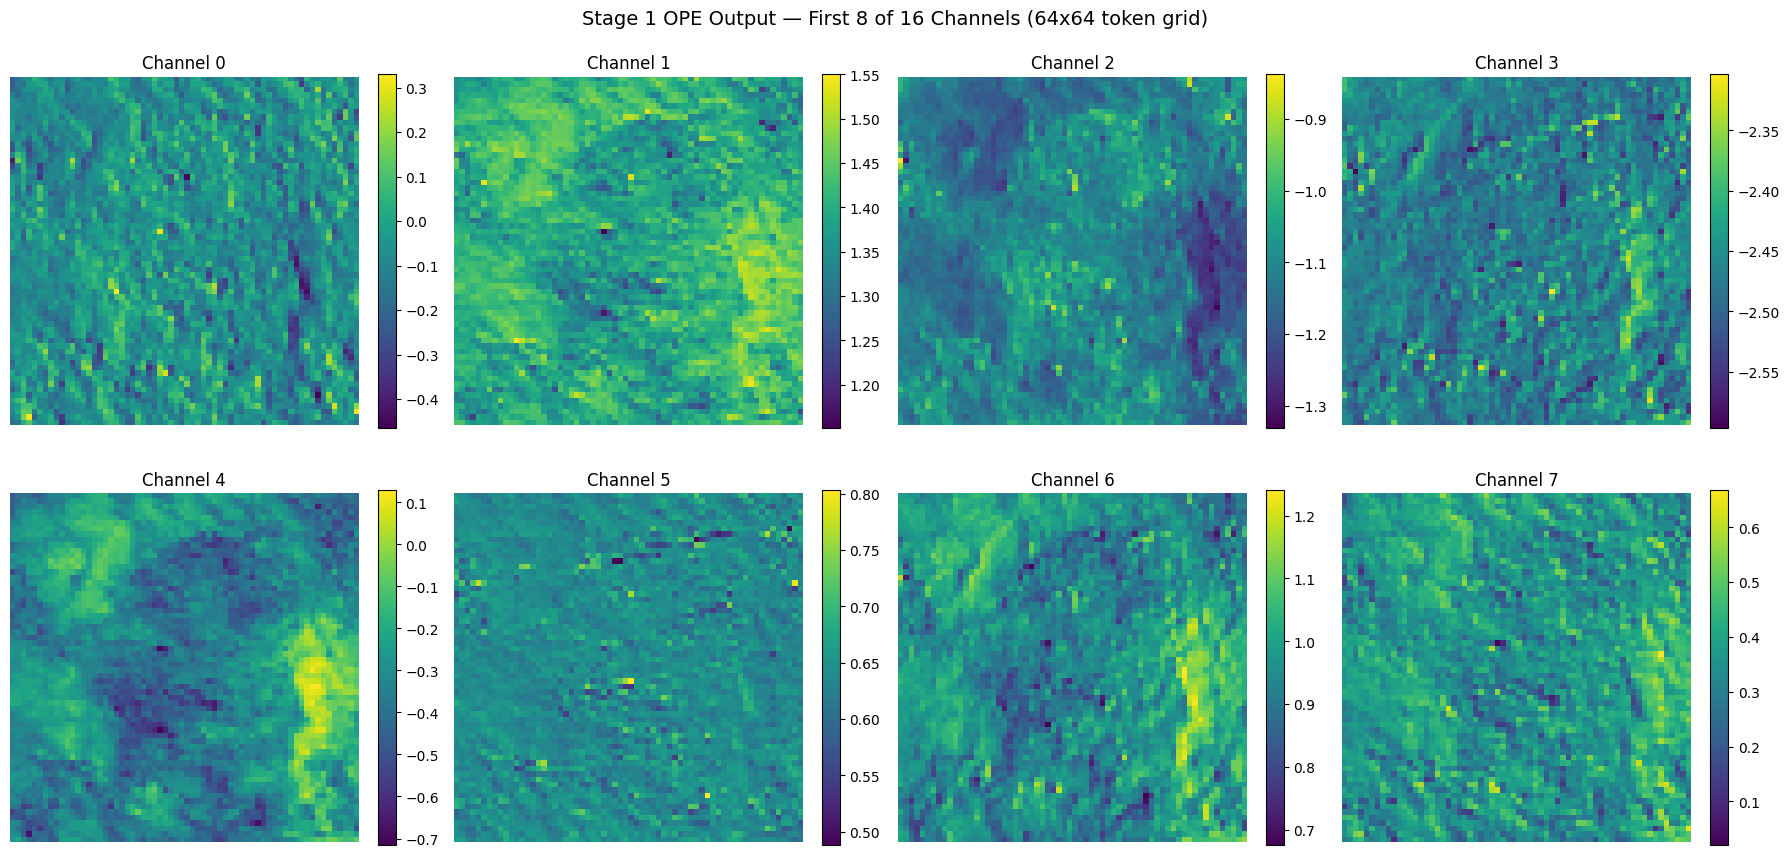

In [103]:
with torch.no_grad():
    # Stage 1 OPE: (1, 1, 256, 256) -> (1, 4096, 16) + H=64, W=64
    stage1_tokens, H1, W1 = model.encoder.patch_embeds[0](x_norm)

print(f"Stage 1 OPE output: {stage1_tokens.shape}  (B, N={H1}x{W1}, C={MODEL_CONFIG['embed_dims'][0]})")
print(f"Token grid: {H1} x {W1} = {H1*W1} tokens")

# Reshape tokens to spatial grid for visualization: (1, 4096, 16) -> (16, 64, 64)
token_grid = stage1_tokens[0].transpose(0, 1).reshape(MODEL_CONFIG["embed_dims"][0], H1, W1)

# Show first 8 channels
n_show = 8
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for idx, ax in enumerate(axes.flat):
    if idx < n_show:
        im = ax.imshow(token_grid[idx].numpy(), cmap="viridis")
        ax.set_title(f"Channel {idx}")
        plt.colorbar(im, ax=ax, fraction=0.046)
    ax.axis("off")
fig.suptitle(f"Stage 1 OPE Output — First {n_show} of {MODEL_CONFIG['embed_dims'][0]} Channels (64x64 token grid)", fontsize=14)
plt.tight_layout()
plt.show()

### 8. Step C — Token Masking: Keep vs. Prediction Targets

`TokenMasking` converts the pixel-level validity mask to token-level validity, then
randomly selects 50% of valid tokens as **prediction targets** (removed from the encoder).

The left plot shows **token validity** (which 4x4 blocks have enough valid pixels).
The right plot shows the **keep mask** — green tokens stay in the encoder, red tokens
are removed and must be reconstructed by the decoder.

Total tokens: 4096
Valid tokens: 4096 (100.0%)
Prediction targets (removed): 2048 (50.0% of valid)
Kept tokens (encoder input): 2048


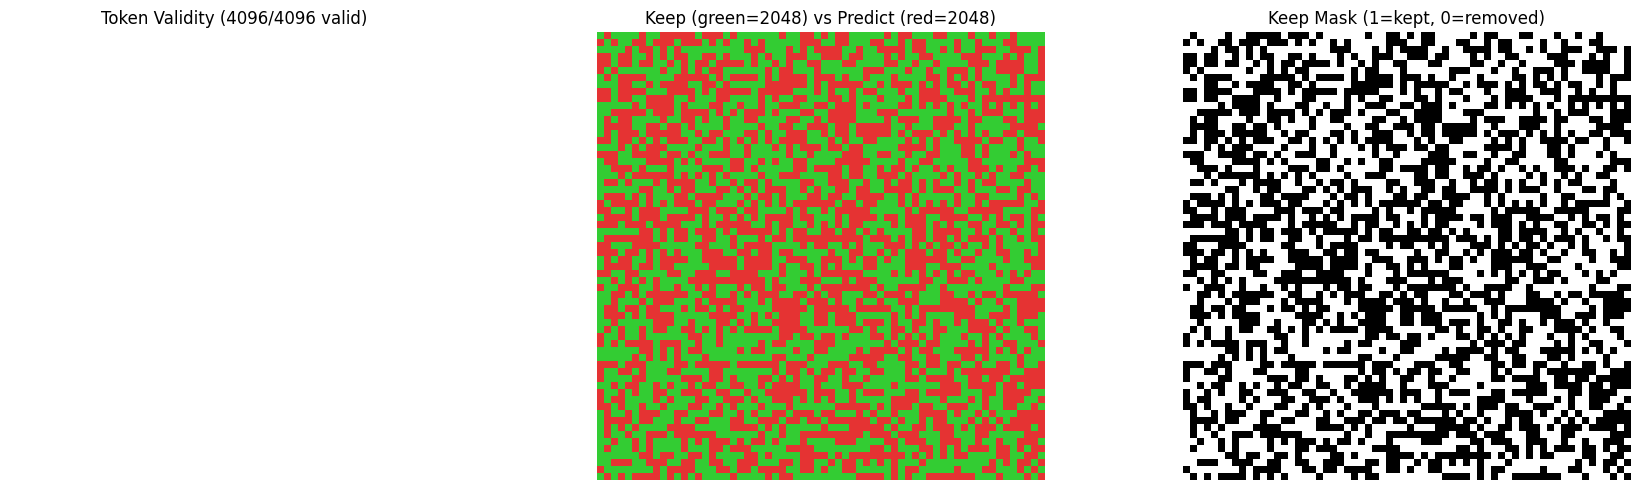

In [104]:
# Token masking parameters (must match Stage 1 OPE: kernel=4, stride=4, padding=0)
STAGE1_KERNEL = 4
STAGE1_STRIDE = 4
STAGE1_PADDING = 0
MASK_RATIO = 0.5

with torch.no_grad():
    # Pixel mask -> token-level validity
    token_validity = TokenMasking.pixel_mask_to_token_mask(
        mask, kernel_size=STAGE1_KERNEL, stride=STAGE1_STRIDE, padding=STAGE1_PADDING
    )  # (1, 4096)

    # Randomly select 50% of valid tokens as prediction targets
    keep_mask, pred_mask = TokenMasking.generate_prediction_mask(
        token_validity, MASK_RATIO, DEVICE
    )  # keep_mask: (1, 4096), pred_mask: (1, 4096)

# Reshape to 64x64 grids for visualization
token_val_grid = token_validity[0].reshape(H1, W1).numpy()
keep_grid = keep_mask[0].reshape(H1, W1).numpy()
pred_grid = pred_mask[0].reshape(H1, W1).numpy()

num_valid = int(token_validity.sum())
num_pred = int(pred_mask.sum())
num_kept = int(keep_mask.sum())

print(f"Total tokens: {H1*W1}")
print(f"Valid tokens: {num_valid} ({num_valid/(H1*W1):.1%})")
print(f"Prediction targets (removed): {num_pred} ({num_pred/max(num_valid,1):.1%} of valid)")
print(f"Kept tokens (encoder input): {num_kept}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(token_val_grid, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Token Validity ({num_valid}/{H1*W1} valid)")

# Color-coded keep/pred/invalid visualization
vis = np.zeros((H1, W1, 3))
vis[keep_grid == 1] = [0.2, 0.8, 0.2]      # Green: kept (visible to encoder)
vis[pred_grid == 1] = [0.9, 0.2, 0.2]      # Red: prediction targets (removed)
vis[token_val_grid == 0] = [0.3, 0.3, 0.3]  # Gray: invalid tokens
axes[1].imshow(vis)
axes[1].set_title(f"Keep (green={num_kept}) vs Predict (red={num_pred})")

# Binary keep mask
axes[2].imshow(keep_grid, cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Keep Mask (1=kept, 0=removed)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 9. Step D — Token Removal and Stage 1 Transformer Block

The prediction target tokens are physically removed from the sequence using `TokenMasking.remove_tokens`.
The encoder only processes the kept tokens (visible + invalid).

We then run the Stage 1 transformer block, which applies:
- **Pre-Norm + Efficient Self-Attention (ESA)** + residual
- **Pre-Norm + MixFFN** (depthwise conv + GELU + linear) + residual

We visualize the tokens **before attention** (raw OPE output, kept subset) and
**after the transformer block** (enriched with spatial context).

Before removal: torch.Size([1, 4096, 16]) (4096 tokens)
After removal:  torch.Size([1, 2048, 16]) (2048 tokens)
After Stage 1 blocks + norm: torch.Size([1, 2048, 16])


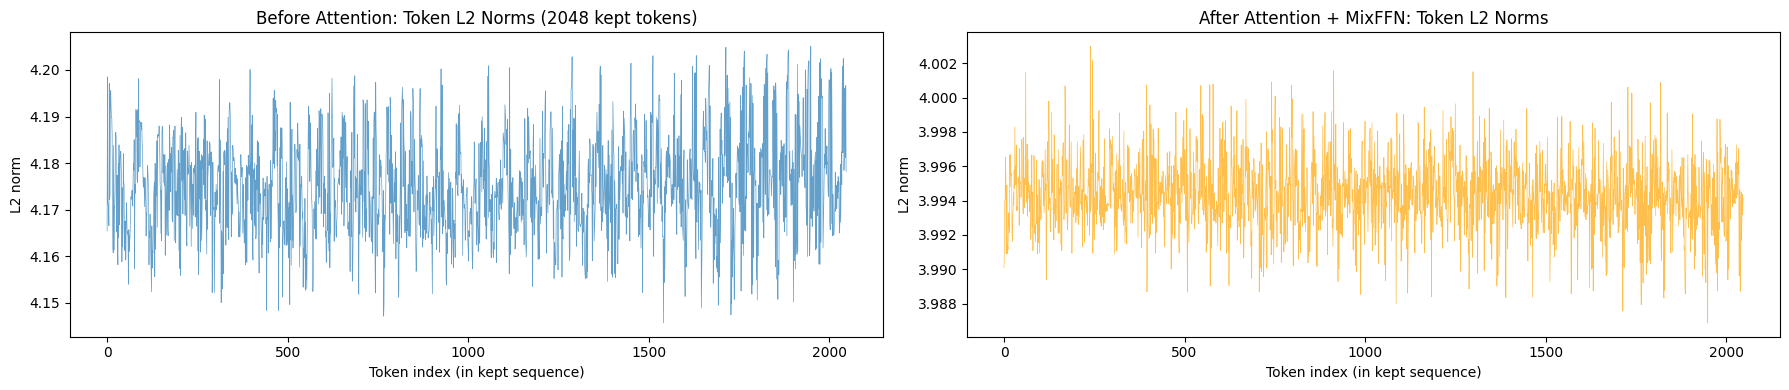

Before attn — mean norm: 4.175, std: 0.011
After attn  — mean norm: 3.994, std: 0.002


In [105]:
with torch.no_grad():
    B, N_full, C1 = stage1_tokens.shape

    # Remove prediction targets
    kept_tokens, gather_indices = TokenMasking.remove_tokens(stage1_tokens, keep_mask)
    # kept_tokens: (1, N_kept, 16), gather_indices: (1, N_kept)

    print(f"Before removal: {stage1_tokens.shape} ({N_full} tokens)")
    print(f"After removal:  {kept_tokens.shape} ({kept_tokens.shape[1]} tokens)")

    # --- Visualize before attention (kept tokens only) ---
    # We need to show the L2 norm of each token embedding to see activation patterns
    before_attn_norm = kept_tokens[0].norm(dim=-1)  # (N_kept,)

    # Run Stage 1 transformer block(s)
    x_stage1 = kept_tokens
    for block in model.encoder.blocks[0]:
        x_stage1 = block(x_stage1, H1, W1)
    # x_stage1: (1, N_kept, 16)

    # Apply stage norm
    x_stage1 = model.encoder.norms[0](x_stage1)

    after_attn_norm = x_stage1[0].norm(dim=-1)  # (N_kept,)

    print(f"After Stage 1 blocks + norm: {x_stage1.shape}")

# Visualize token norms as 1D bar chart (too sparse for 2D grid)
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

axes[0].plot(before_attn_norm.numpy(), linewidth=0.5, alpha=0.7)
axes[0].set_title(f"Before Attention: Token L2 Norms ({kept_tokens.shape[1]} kept tokens)")
axes[0].set_xlabel("Token index (in kept sequence)")
axes[0].set_ylabel("L2 norm")

axes[1].plot(after_attn_norm.numpy(), linewidth=0.5, alpha=0.7, color="orange")
axes[1].set_title(f"After Attention + MixFFN: Token L2 Norms")
axes[1].set_xlabel("Token index (in kept sequence)")
axes[1].set_ylabel("L2 norm")

plt.tight_layout()
plt.show()

print(f"Before attn — mean norm: {before_attn_norm.mean():.3f}, std: {before_attn_norm.std():.3f}")
print(f"After attn  — mean norm: {after_attn_norm.mean():.3f}, std: {after_attn_norm.std():.3f}")

### 10. Step E — Scatter-Back: Full 64x64 Token Grid

After the encoder finishes Stage 1, the kept tokens are scattered back to their
original positions in the full 64x64 grid. Positions where prediction targets were
removed are filled with **zeros** — these are the gaps the decoder must reconstruct.

We visualize the full grid's L2 norm per token: zero-norm positions (black) are the
masked tokens.

Restored tokens: torch.Size([1, 4096, 16])
F1 feature map: torch.Size([1, 16, 64, 64])


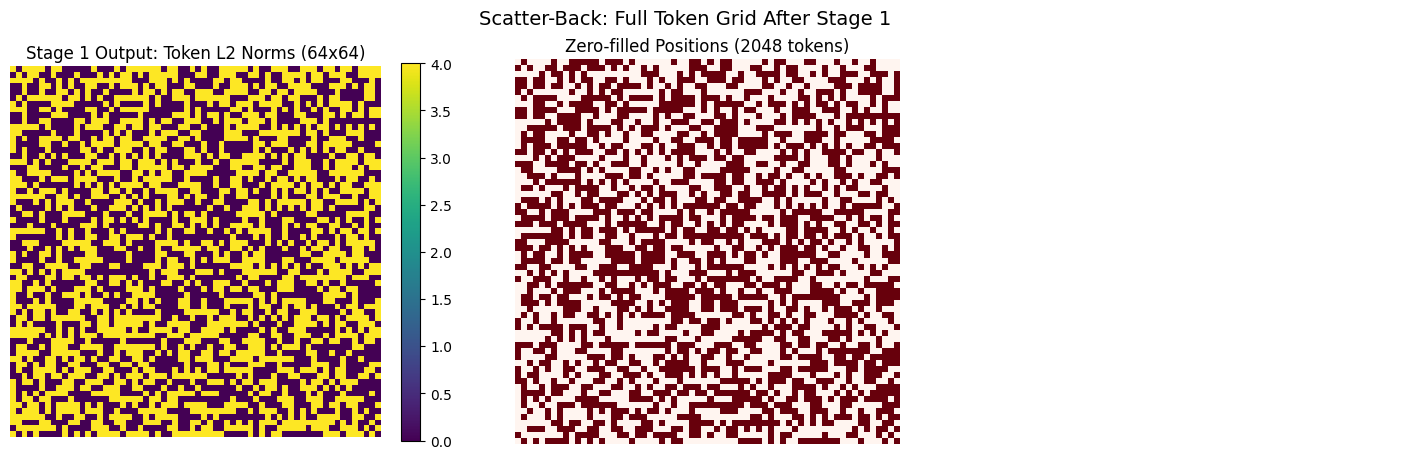

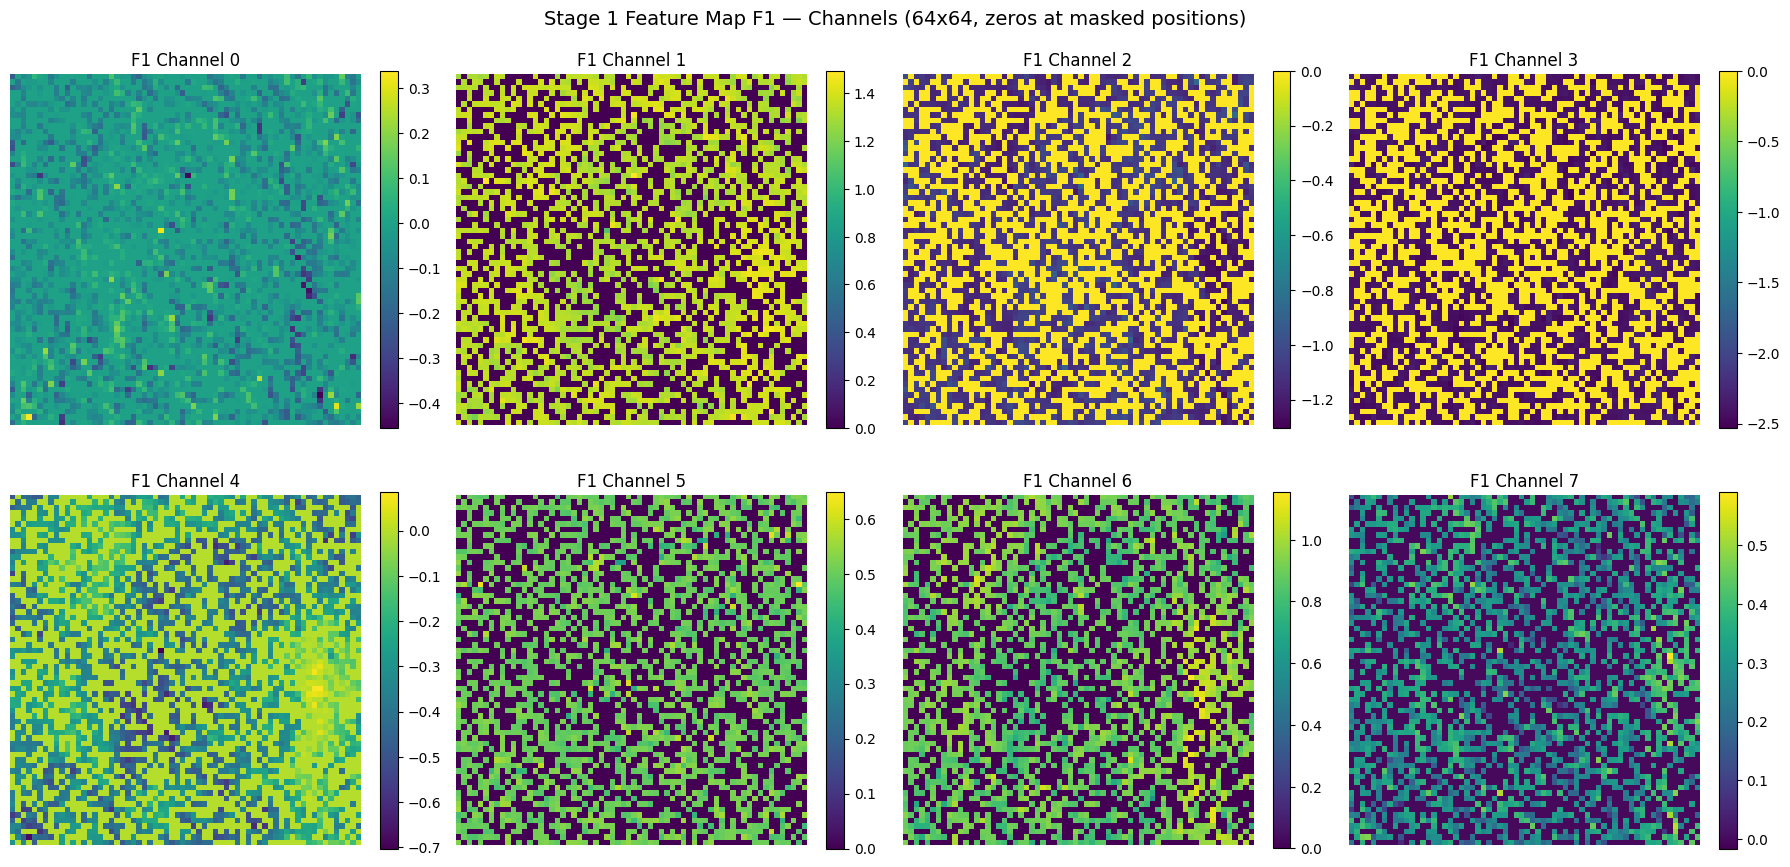

In [106]:
with torch.no_grad():
    # Scatter kept tokens back into full grid
    restored_tokens = TokenMasking.restore_tokens(
        x_stage1, gather_indices, N_full, C1
    )  # (1, 4096, 16)

    # Reshape to 2D spatial form: (1, 4096, 16) -> (1, 16, 64, 64)
    F1 = restored_tokens.transpose(1, 2).reshape(1, C1, H1, W1)

print(f"Restored tokens: {restored_tokens.shape}")
print(f"F1 feature map: {F1.shape}")

# Visualize L2 norm per token in the full grid
token_norms_full = restored_tokens[0].norm(dim=-1).reshape(H1, W1).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(token_norms_full, cmap="viridis")
axes[0].set_title("Stage 1 Output: Token L2 Norms (64x64)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Show the zero positions (masked tokens)
zero_mask_vis = (token_norms_full == 0).astype(float)
axes[1].imshow(zero_mask_vis, cmap="Reds", vmin=0, vmax=1)
axes[1].set_title(f"Zero-filled Positions ({int(zero_mask_vis.sum())} tokens)")

# Show a few channels of F1
n_show = 4
for idx in range(n_show):
    pass  # Will show in next subplot

# Show first 4 channels of F1 as a 2x2 grid
fig2, axes2 = plt.subplots(2, 4, figsize=(18, 9))
for idx, ax in enumerate(axes2.flat):
    if idx < min(8, C1):
        im = ax.imshow(F1[0, idx].numpy(), cmap="viridis")
        ax.set_title(f"F1 Channel {idx}")
        plt.colorbar(im, ax=ax, fraction=0.046)
    ax.axis("off")
fig2.suptitle("Stage 1 Feature Map F1 — Channels (64x64, zeros at masked positions)", fontsize=14)

for ax in axes:
    ax.axis("off")
fig.suptitle("Scatter-Back: Full Token Grid After Stage 1", fontsize=14)
plt.tight_layout()
plt.show()

### 11. Step F — Stages 2-4 Feature Maps

Stages 2-4 process ALL tokens (no removal). Each stage:
1. **OPE** with `kernel=3, stride=2` — halves spatial dims, increases channels
2. **Transformer blocks** — attention + MixFFN at that resolution
3. **LayerNorm** — normalize the output

Spatial progression:
- **F1:** 64x64 x 16 channels (from Stage 1, with zeros at masked positions)
- **F2:** 32x32 x 32 channels (Stage 2 OPE pools over the masked gaps)
- **F3:** 16x16 x 64 channels
- **F4:** 8x8 x 96 channels (coarsest — captures global scene structure)

Stage 2: F2 = torch.Size([1, 32, 32, 32])  (32x32 spatial, 32 channels)
Stage 3: F3 = torch.Size([1, 64, 16, 16])  (16x16 spatial, 64 channels)
Stage 4: F4 = torch.Size([1, 96, 8, 8])  (8x8 spatial, 96 channels)


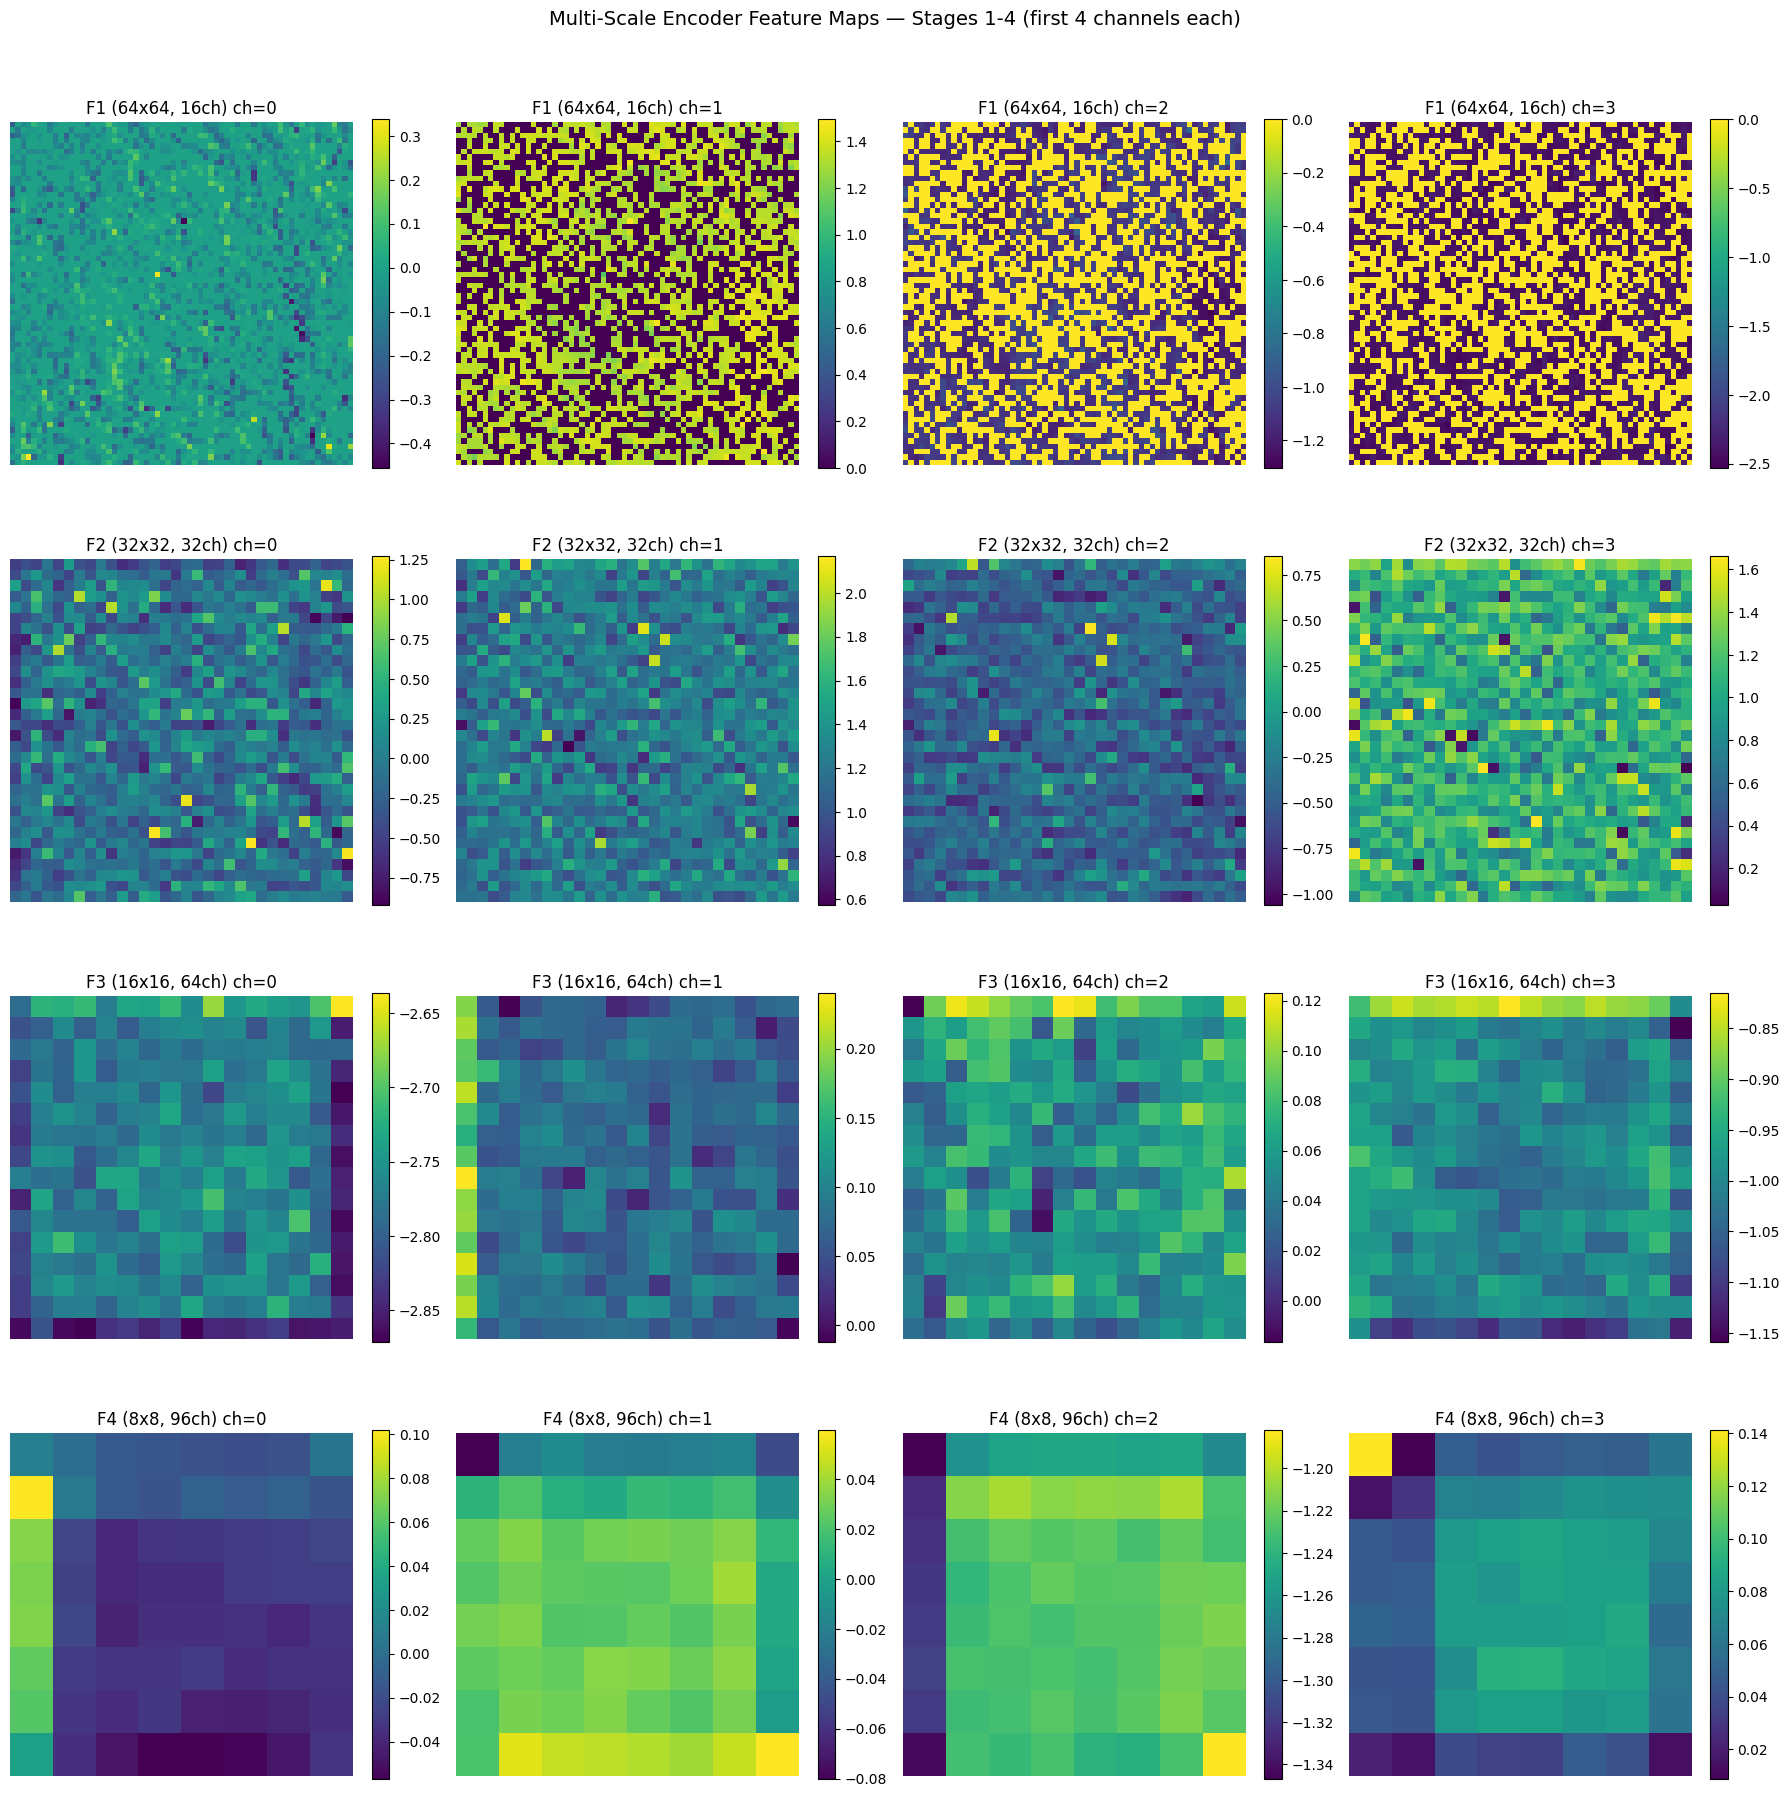

In [107]:
with torch.no_grad():
    # Run stages 2-4 sequentially, starting from F1
    features = [F1]  # Already computed Stage 1 output
    x_spatial = F1    # (1, 16, 64, 64)

    for stage_idx in range(1, model.encoder.num_stages):
        # OPE: downsample and re-embed
        tokens_s, Hs, Ws = model.encoder.patch_embeds[stage_idx](x_spatial)

        # Transformer blocks
        for block in model.encoder.blocks[stage_idx]:
            tokens_s = block(tokens_s, Hs, Ws)

        # Stage norm
        tokens_s = model.encoder.norms[stage_idx](tokens_s)

        # Reshape to 2D
        Bs, Ns, Cs = tokens_s.shape
        x_spatial = tokens_s.transpose(1, 2).reshape(Bs, Cs, Hs, Ws)
        features.append(x_spatial)

        print(f"Stage {stage_idx+1}: F{stage_idx+1} = {x_spatial.shape}  "
              f"({Hs}x{Ws} spatial, {Cs} channels)")

# Visualize first 4 channels of each stage
fig, axes = plt.subplots(4, 4, figsize=(18, 18))
stage_names = ["F1 (64x64, 16ch)", "F2 (32x32, 32ch)", "F3 (16x16, 64ch)", "F4 (8x8, 96ch)"]

for stage_idx, feat in enumerate(features):
    n_ch = feat.shape[1]
    for ch_idx in range(4):
        ax = axes[stage_idx, ch_idx]
        if ch_idx < n_ch:
            im = ax.imshow(feat[0, ch_idx].numpy(), cmap="viridis")
            ax.set_title(f"{stage_names[stage_idx]} ch={ch_idx}")
            plt.colorbar(im, ax=ax, fraction=0.046)
        ax.axis("off")

fig.suptitle("Multi-Scale Encoder Feature Maps — Stages 1-4 (first 4 channels each)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 12. Step G — Decoder: Multi-Scale Fusion at H/4 Resolution

The decoder takes `[F1, F2, F3, F4]` and:
1. Projects each to a common `decoder_dim=96` channels via 1x1 Conv
2. Upsamples all to F1's resolution (64x64) via bilinear interpolation
3. Concatenates along channels: `(B, 4*96, 64, 64)`
4. Fuses with 1x1 Conv + GELU back to `(B, 96, 64, 64)`

This fused representation contains information from all spatial scales.

Unified F1: torch.Size([1, 16, 64, 64]) -> project -> upsample -> torch.Size([1, 96, 64, 64])
Unified F2: torch.Size([1, 32, 32, 32]) -> project -> upsample -> torch.Size([1, 96, 64, 64])
Unified F3: torch.Size([1, 64, 16, 16]) -> project -> upsample -> torch.Size([1, 96, 64, 64])
Unified F4: torch.Size([1, 96, 8, 8]) -> project -> upsample -> torch.Size([1, 96, 64, 64])

Concatenated: torch.Size([1, 384, 64, 64])  (4 x 96 = 384 channels)
Fused: torch.Size([1, 96, 64, 64])


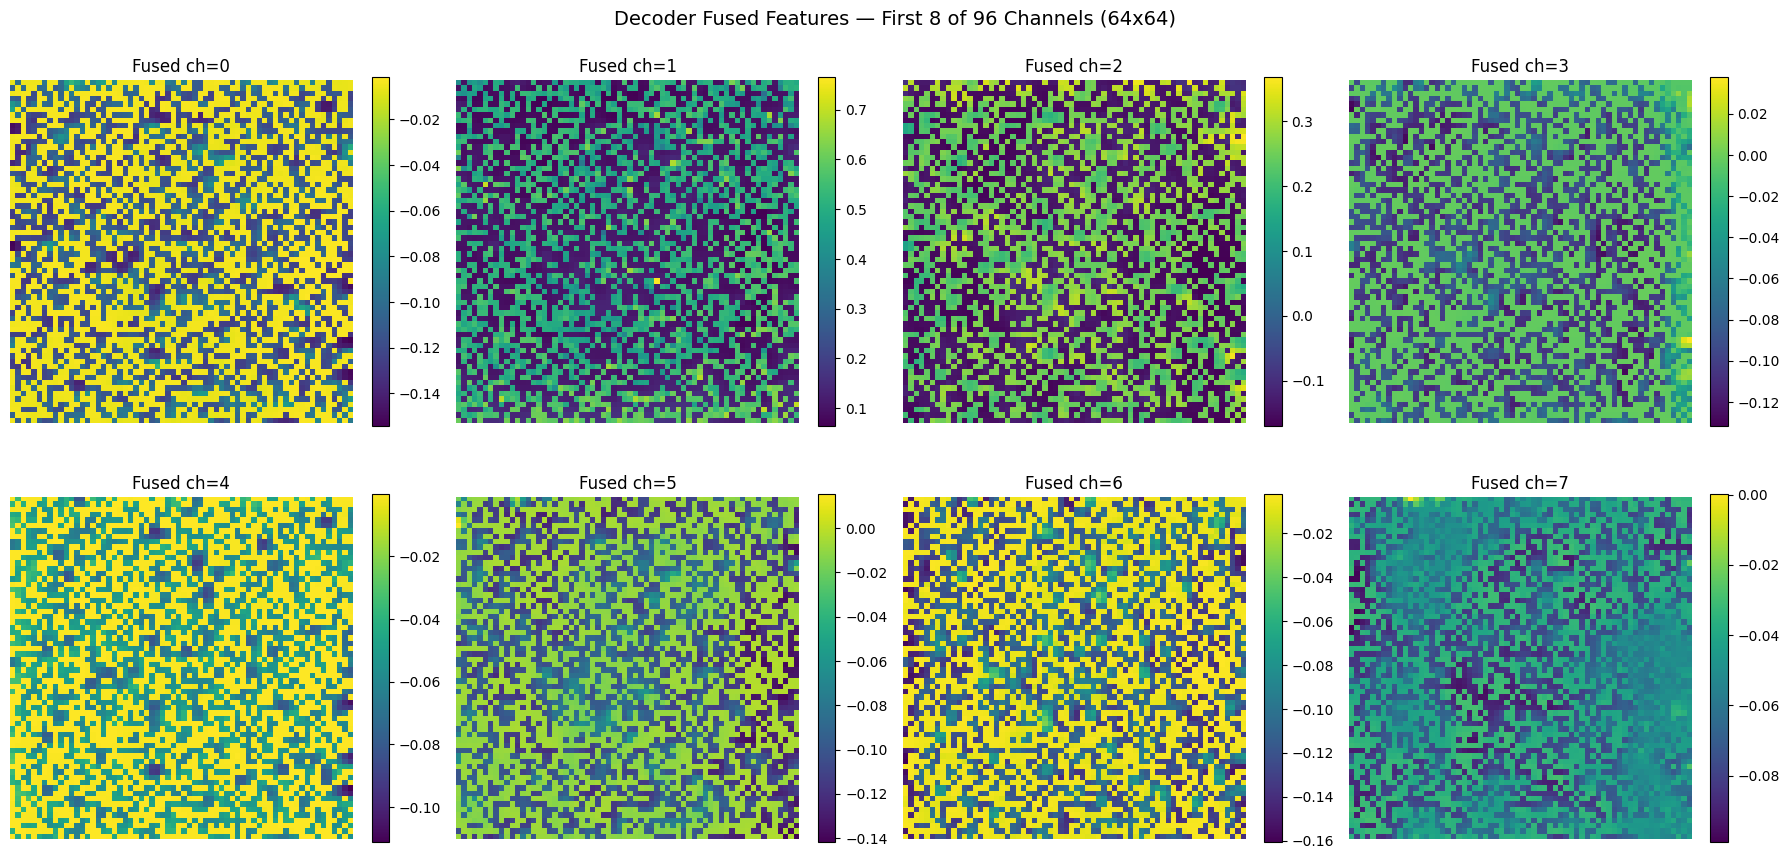

In [108]:
with torch.no_grad():
    decoder = model.decoder
    target_h, target_w = features[0].shape[2], features[0].shape[3]

    # Step 1-2: Project each feature map and upsample to target resolution
    unified = []
    for i, feat in enumerate(features):
        proj = decoder.linear_projections[i](feat)
        if proj.shape[2] != target_h or proj.shape[3] != target_w:
            proj = F.interpolate(proj, size=(target_h, target_w),
                                 mode='bilinear', align_corners=False)
        unified.append(proj)
        print(f"Unified F{i+1}: {feat.shape} -> project -> upsample -> {proj.shape}")

    # Step 3: Concatenate
    concatenated = torch.cat(unified, dim=1)
    print(f"\nConcatenated: {concatenated.shape}  (4 x {MODEL_CONFIG['decoder_dim']} = {4*MODEL_CONFIG['decoder_dim']} channels)")

    # Step 4: Fuse
    fused = decoder.fuse_conv(concatenated)
    fused = decoder.fuse_act(fused)
    print(f"Fused: {fused.shape}")

# Visualize fused features (first 8 channels)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for idx, ax in enumerate(axes.flat):
    if idx < 8:
        im = ax.imshow(fused[0, idx].numpy(), cmap="viridis")
        ax.set_title(f"Fused ch={idx}")
        plt.colorbar(im, ax=ax, fraction=0.046)
    ax.axis("off")
fig.suptitle(f"Decoder Fused Features — First 8 of {MODEL_CONFIG['decoder_dim']} Channels (64x64)", fontsize=14)
plt.tight_layout()
plt.show()

### 13. Step H — Refine Conv and PixelShuffle

The decoder's refine stage operates at H/4 (64x64) resolution:
1. **Conv3x3 + GELU** — refines spatial features (effective receptive field = 12x12 original pixels)
2. **Conv3x3** (no activation) — produces `out_channels * 16` channels (16 sub-pixel values per position)
3. **PixelShuffle(4)** — rearranges each group of 16 channels into a 4x4 spatial block

This gives us the final `(B, 1, 256, 256)` reconstruction in normalized space.
We then denormalize back to degrees Celsius.

Refine output (before PixelShuffle): torch.Size([1, 16, 64, 64])
  = 16 channels at 64x64
  = 1 output channel x 4x4 = 16 sub-pixel values per position

After PixelShuffle(4): torch.Size([1, 1, 256, 256])
After denormalization: torch.Size([1, 1, 256, 256])


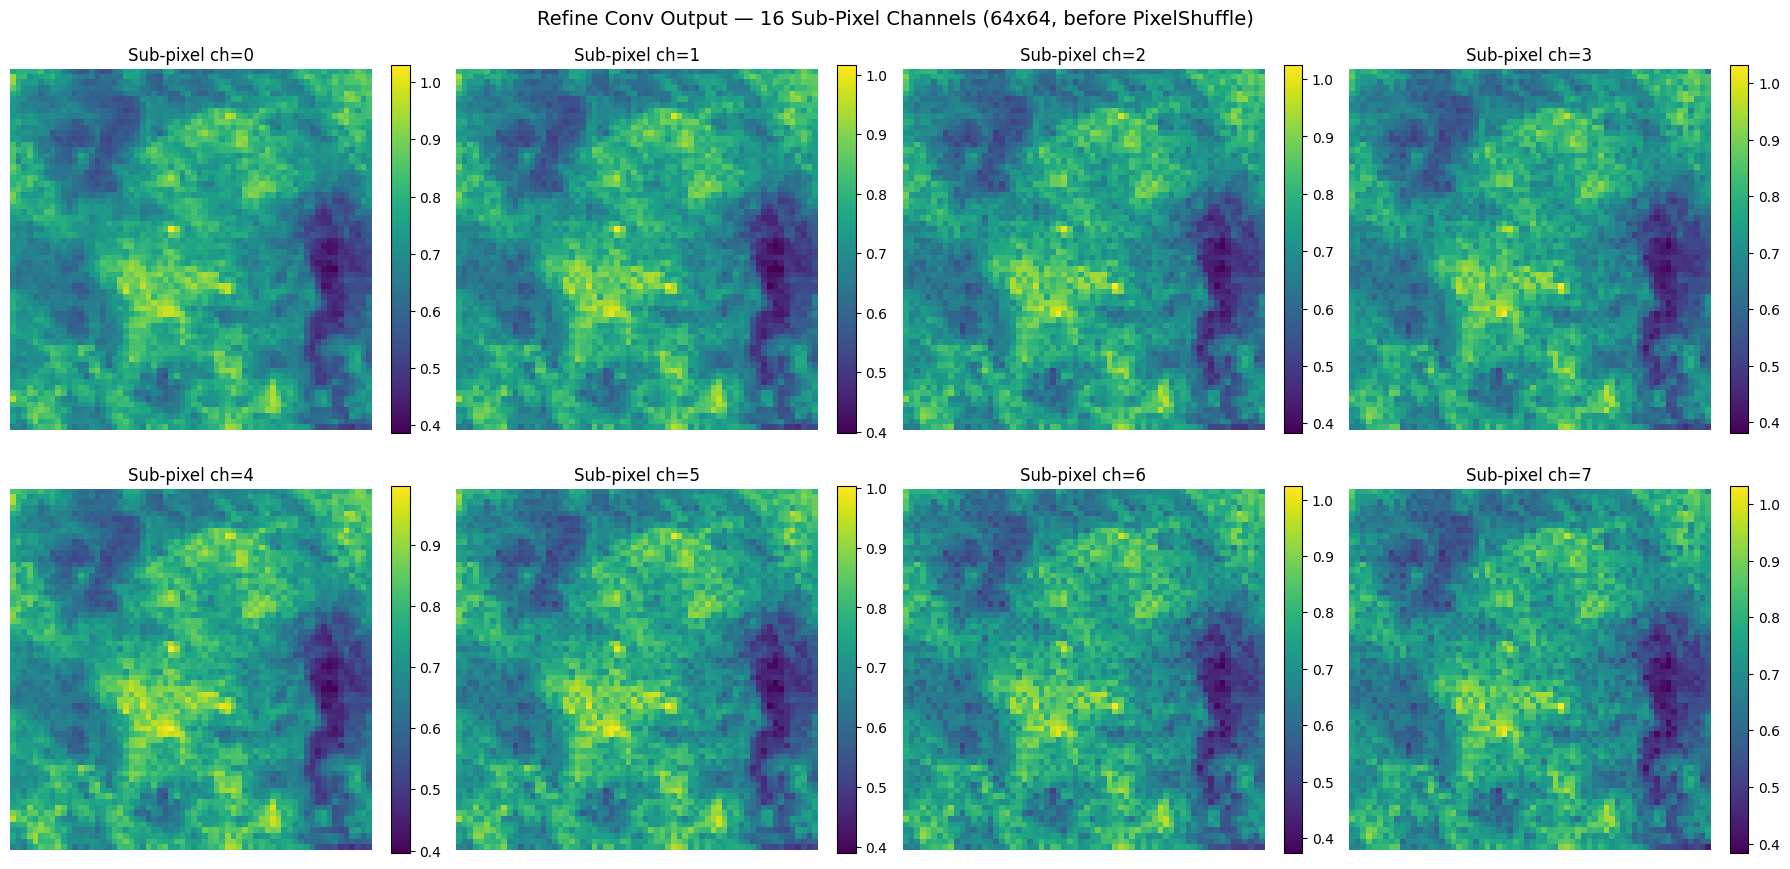

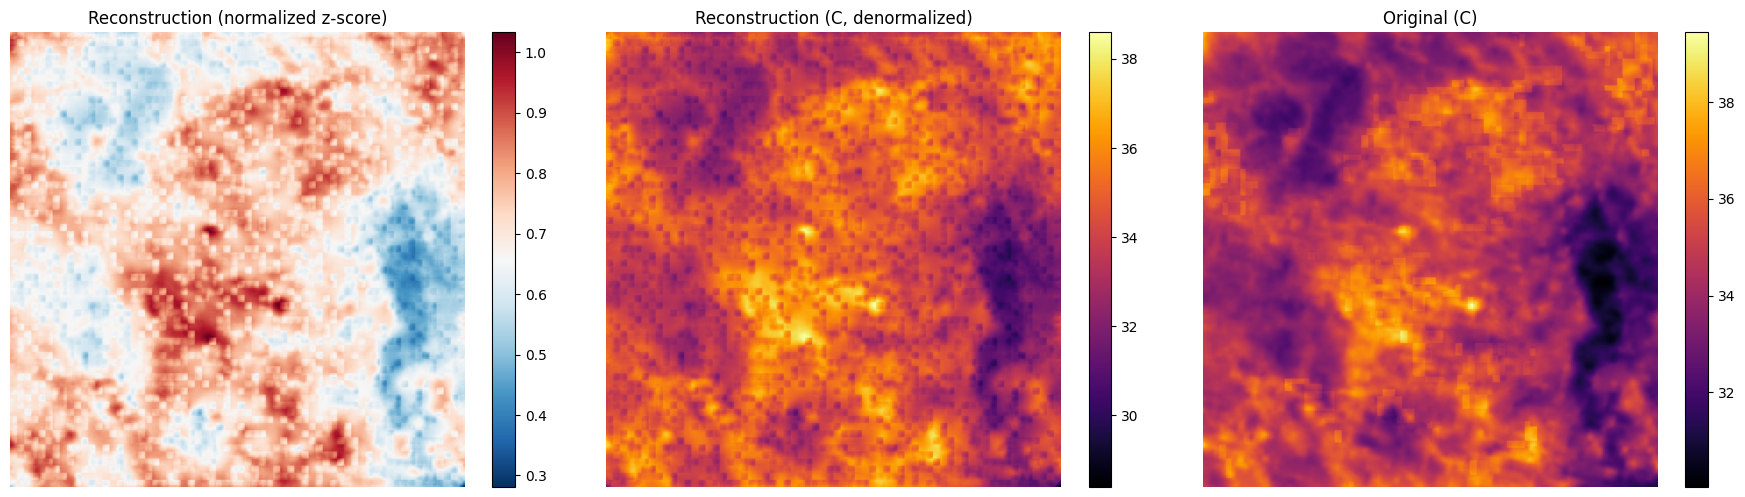

In [109]:
with torch.no_grad():
    # Run the refine sequential (Conv3x3 + GELU, Conv3x3)
    refined = decoder.refine(fused)
    print(f"Refine output (before PixelShuffle): {refined.shape}")
    print(f"  = {refined.shape[1]} channels at {refined.shape[2]}x{refined.shape[3]}")
    print(f"  = {MODEL_CONFIG['in_channels']} output channel x 4x4 = 16 sub-pixel values per position")

    # PixelShuffle: (B, 16, 64, 64) -> (B, 1, 256, 256)
    x_hat_norm = F.pixel_shuffle(refined, 4)
    print(f"\nAfter PixelShuffle(4): {x_hat_norm.shape}")

    # Denormalize back to temperature space
    x_hat = model.denormalize(x_hat_norm)
    print(f"After denormalization: {x_hat.shape}")

# Visualize the refine output channels (sub-pixel values before shuffle)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for idx, ax in enumerate(axes.flat):
    if idx < refined.shape[1]:
        im = ax.imshow(refined[0, idx].numpy(), cmap="viridis")
        ax.set_title(f"Sub-pixel ch={idx}")
        plt.colorbar(im, ax=ax, fraction=0.046)
    ax.axis("off")
fig.suptitle("Refine Conv Output — 16 Sub-Pixel Channels (64x64, before PixelShuffle)", fontsize=14)
plt.tight_layout()
plt.show()

# Show PixelShuffle result side by side with original
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(x_hat_norm[0, 0].numpy(), cmap="RdBu_r")
axes[0].set_title("Reconstruction (normalized z-score)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(x_hat[0, 0].numpy(), cmap="inferno")
axes[1].set_title("Reconstruction (C, denormalized)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(pixels[0, 0].numpy(), cmap="inferno")
axes[2].set_title("Original (C)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 14. Step I — Residual Map: |Original - Reconstruction|

The per-pixel absolute residual is the anomaly signal. Regions the network cannot
reconstruct from spatial context (because they are anomalous / out-of-distribution)
produce high residual values.

We show:
- The absolute residual map
- A histogram of residual values
- The residual overlaid with ground truth anomaly locations

Residual stats (valid pixels only):
  Mean: 0.353 C
  Std:  0.323 C
  Max:  3.370 C
  P95:  0.994 C
  P99:  1.328 C


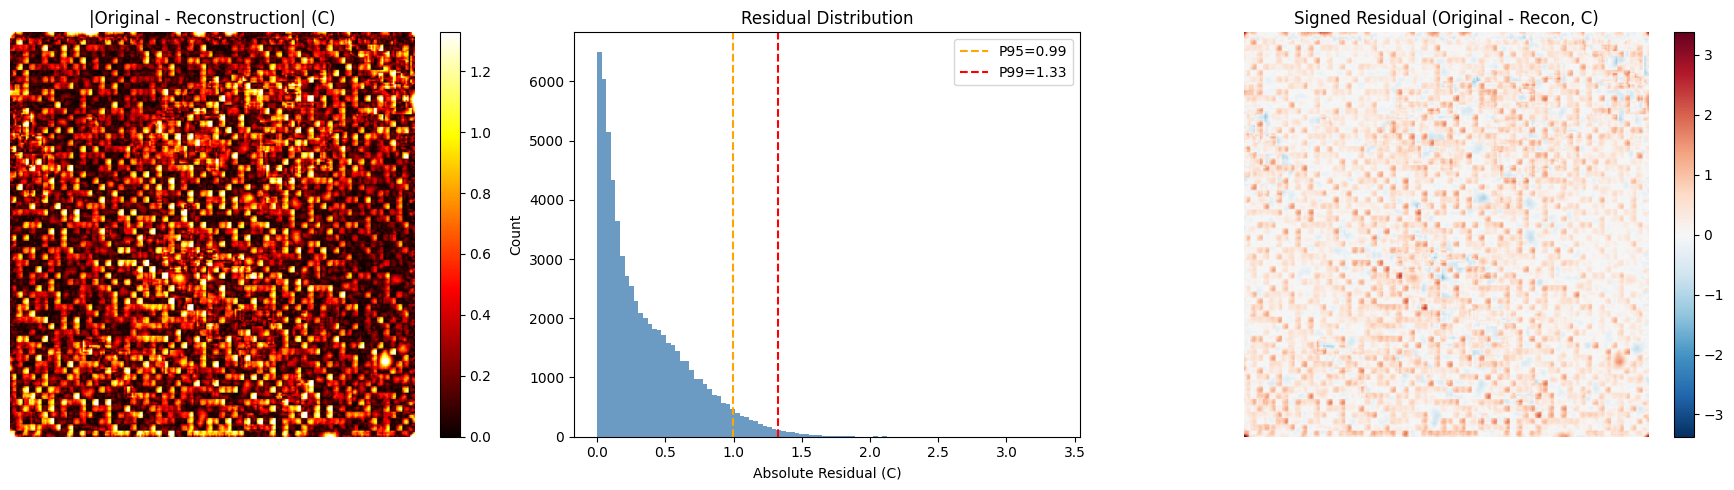

In [110]:
residual = (pixels - x_hat).abs()  # (1, 1, 256, 256)
residual_np = residual[0, 0].numpy()

# Mask invalid pixels
residual_valid = residual_np * patch_mask[0]

print(f"Residual stats (valid pixels only):")
valid_residuals = residual_valid[patch_mask[0] > 0]
print(f"  Mean: {valid_residuals.mean():.3f} C")
print(f"  Std:  {valid_residuals.std():.3f} C")
print(f"  Max:  {valid_residuals.max():.3f} C")
print(f"  P95:  {np.percentile(valid_residuals, 95):.3f} C")
print(f"  P99:  {np.percentile(valid_residuals, 99):.3f} C")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual map
# Use RdBu centered at 0 — but since these are absolute values, use a sequential colormap
im0 = axes[0].imshow(residual_valid, cmap="hot", vmin=0,
                      vmax=np.percentile(valid_residuals, 99))
axes[0].set_title("|Original - Reconstruction| (C)")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

# Histogram
axes[1].hist(valid_residuals, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[1].axvline(np.percentile(valid_residuals, 95), color="orange",
                linestyle="--", label=f"P95={np.percentile(valid_residuals, 95):.2f}")
axes[1].axvline(np.percentile(valid_residuals, 99), color="red",
                linestyle="--", label=f"P99={np.percentile(valid_residuals, 99):.2f}")
axes[1].set_xlabel("Absolute Residual (C)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")
axes[1].legend()

# Signed residual for RdBu visualization
signed_residual = (pixels[0, 0] - x_hat[0, 0]).numpy() * patch_mask[0]
abs_max = max(abs(signed_residual[patch_mask[0] > 0].min()),
              abs(signed_residual[patch_mask[0] > 0].max()))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)
im2 = axes[2].imshow(signed_residual, cmap="RdBu_r", norm=norm)
axes[2].set_title("Signed Residual (Original - Recon, C)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in [axes[0], axes[2]]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 15. Step J — Residual Overlaid with Ground Truth Anomalies

The final visualization overlays the residual map with ground truth anomaly locations.
If the model has learned good background reconstruction, anomalous pixels (marked in
the ground truth) should align with high residual values.

**Note:** With random weights (no checkpoint loaded), the residual is meaningless.
Load a trained checkpoint to see meaningful anomaly detection.

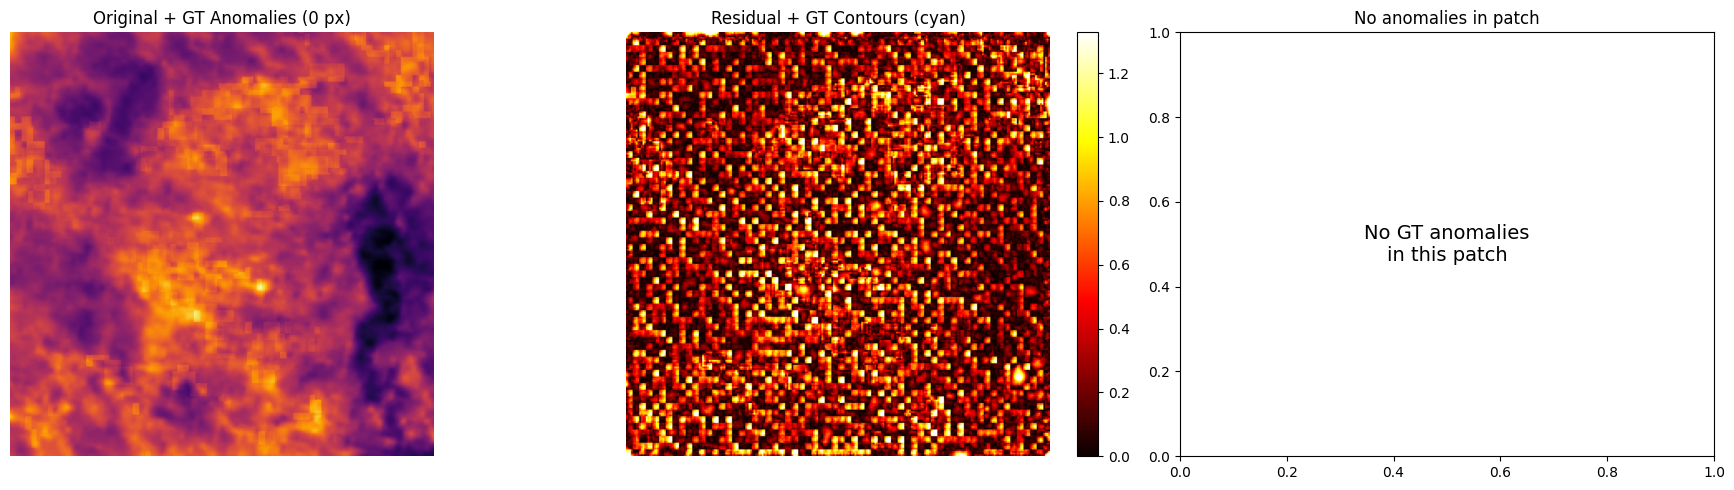


Summary of the SegFormer MAE data flow:
  Input:       (1, 1, 256, 256)  raw thermal in Celsius
  Masked:      (1, 1, 256, 256)  invalid pixels zeroed
  Normalized:  (1, 1, 256, 256)  z-score space
  Stage 1 OPE: (1, 4096, 16)     64x64 token grid, 16-dim embeddings
  Token remove:(1, 2048, 16)     ~50% of valid tokens kept
  Stage 1 out: (1, 4096, 16)     scatter back to full grid (zeros at masked)
  F1:          (1, 16, 64, 64)
  F2:          (1, 32, 32, 32)
  F3:          (1, 64, 16, 16)
  F4:          (1, 96, 8, 8)
  Fused:       (1, 96, 64, 64)   multi-scale features at H/4
  Refined:     (1, 16, 64, 64)   sub-pixel channels before shuffle
  Output:      (1, 1, 256, 256)  reconstruction in Celsius


In [111]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Original with GT overlay
axes[0].imshow(patch_thermal[0], cmap="inferno")
if patch_gt.sum() > 0:
    gt_overlay = np.ma.masked_where(patch_gt == 0, patch_gt)
    axes[0].imshow(gt_overlay, cmap="spring", alpha=0.9, vmin=0, vmax=1)
axes[0].set_title(f"Original + GT Anomalies ({int(patch_gt.sum())} px)")

# Panel 2: Residual map with GT contours
im1 = axes[1].imshow(residual_valid, cmap="hot", vmin=0,
                      vmax=np.percentile(valid_residuals, 99))
if patch_gt.sum() > 0:
    axes[1].contour(patch_gt, levels=[0.5], colors="cyan", linewidths=1.5)
axes[1].set_title("Residual + GT Contours (cyan)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Panel 3: Side-by-side comparison — reconstruction vs original
diff_display = x_hat[0, 0].numpy() * patch_mask[0]
original_display = pixels[0, 0].numpy() * patch_mask[0]

# Compute correlation between residual and GT for valid pixels
if patch_gt.sum() > 0:
    gt_flat = patch_gt[patch_mask[0] > 0].flatten()
    res_flat = residual_valid[patch_mask[0] > 0].flatten()
    # Mean residual at anomaly vs normal pixels
    anom_residual = res_flat[gt_flat > 0].mean() if gt_flat.sum() > 0 else 0
    normal_residual = res_flat[gt_flat == 0].mean()
    axes[2].bar(["Normal pixels", "Anomaly pixels"],
                [normal_residual, anom_residual],
                color=["steelblue", "firebrick"], edgecolor="black")
    axes[2].set_ylabel("Mean |Residual| (C)")
    axes[2].set_title(f"Anomaly vs Normal Residual\n(Anomaly: {anom_residual:.2f} C, Normal: {normal_residual:.2f} C)")
else:
    axes[2].text(0.5, 0.5, "No GT anomalies\nin this patch",
                 ha="center", va="center", fontsize=14, transform=axes[2].transAxes)
    axes[2].set_title("No anomalies in patch")

for ax in [axes[0], axes[1]]:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\nSummary of the SegFormer MAE data flow:")
print(f"  Input:       (1, 1, 256, 256)  raw thermal in Celsius")
print(f"  Masked:      (1, 1, 256, 256)  invalid pixels zeroed")
print(f"  Normalized:  (1, 1, 256, 256)  z-score space")
print(f"  Stage 1 OPE: (1, 4096, 16)     64x64 token grid, 16-dim embeddings")
print(f"  Token remove:(1, {kept_tokens.shape[1]}, 16)     ~50% of valid tokens kept")
print(f"  Stage 1 out: (1, 4096, 16)     scatter back to full grid (zeros at masked)")
print(f"  F1:          (1, 16, 64, 64)")
print(f"  F2:          (1, 32, 32, 32)")
print(f"  F3:          (1, 64, 16, 16)")
print(f"  F4:          (1, 96, 8, 8)")
print(f"  Fused:       (1, 96, 64, 64)   multi-scale features at H/4")
print(f"  Refined:     (1, 16, 64, 64)   sub-pixel channels before shuffle")
print(f"  Output:      (1, 1, 256, 256)  reconstruction in Celsius")